In [10]:

import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astroquery.hips2fits import hips2fits
import numpy as np
import warnings
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from reproject import reproject_interp
from astropy.io import fits
import astropy.units as u
import plotfancy as pf
# pf.housestyle_rcparams()
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import os
from glob import glob


In [5]:
input_hdu = hips2fits.query(
            hips='CDS/P/DM/I/350/gaiaedr3',
            width=4096,
            height=2048,
            ra=90 * u.deg,
            dec=90 * u.deg,
            fov=360 * u.deg,
            projection='MOL',
            coordsys='galactic',
            format='fits'
        )

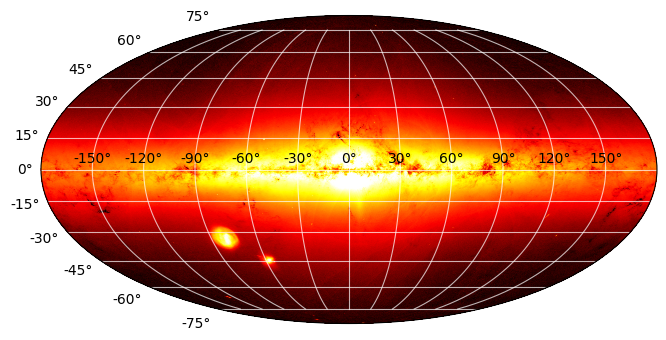

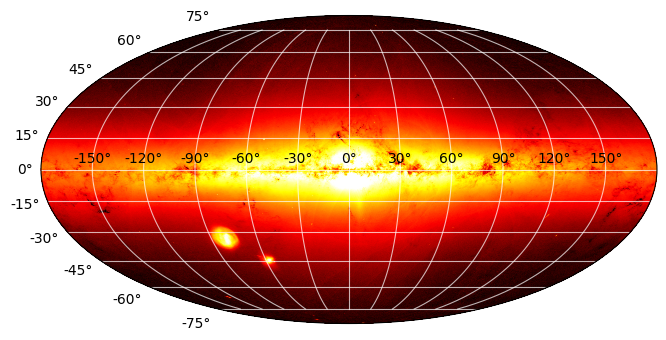

KeyboardInterrupt: 

In [8]:
hdu = input_hdu[0]
wcs = WCS(hdu.header)
image_data = hdu.data.copy() 
image_data[np.isnan(image_data)] = 0  
with np.errstate(divide='ignore'):
    plot_data = np.log1p(image_data)  

vmin = np.percentile(plot_data[plot_data > 0], 1) 
vmax = np.percentile(plot_data, 99.5) 
norm = Normalize(vmin=vmin, vmax=vmax)

ny, nx = plot_data.shape  
pix_x, pix_y = np.meshgrid(np.arange(nx), np.arange(ny))   
world_coords = wcs.pixel_to_world(pix_x, pix_y) 
lon = world_coords.l.wrap_at(180 * u.deg).radian
lat = world_coords.b.radian

finite_mask = np.isfinite(lon) & np.isfinite(lat) 
lon = lon[finite_mask] 
lat = lat[finite_mask] 
plot_data_filtered = plot_data[finite_mask]  

fig = plt.figure(figsize=(8, 4)) 
ax = fig.add_subplot(111, projection='mollweide')  
im = ax.scatter(lon, lat, c=plot_data_filtered, cmap='hot', norm=norm, s=0.1)  
ax.grid(True, color='white', ls='solid', alpha=0.7)  
plt.show()

In [15]:
search_path = os.path.join('../../../../cubes/', '**', '*.fits*')
cube_files = glob(search_path, recursive=True)


print(f"Found {len(cube_files)} FITS files to process.")
all_footprints_deg = []
all_centers_deg = []

for i, f in enumerate(cube_files):
    try:
        with fits.open(f) as hdul:
            wcs_header = None
            for hdu in hdul:
                if (hdu.header.get('CTYPE1') and hdu.header.get('CTYPE2') and
                    hdu.header.get('NAXIS', 0) >= 2):
                    wcs_header = hdu.header
                    break
            if wcs_header is None:
                raise ValueError("No valid WCS found.")

            wcs = WCS(wcs_header)
            footprint = wcs.celestial.calc_footprint()
            center = wcs.celestial.wcs.crval
            all_footprints_deg.append(footprint)
            all_centers_deg.append(center)
    except Exception as e:
        print(f"Warning: Could not process file {os.path.basename(f)}. Reason: {e}")
        continue

if not all_centers_deg:
    print("Error: Could not extract valid WCS information from any FITS files.")

# --- 2. Create the all-sky plot ---
print("\nGenerating all-sky plot...")
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="mollweide")

# --- Plot markers and footprints ---
# Plot a visible marker for the center of each field
for center_deg in all_centers_deg:
    # Convert RA to radians in the range [-pi, pi] for Mollweide
    ra_rad = np.deg2rad(center_deg[0])
    ra_rad = ra_rad if ra_rad <= np.pi else ra_rad - 2 * np.pi
    dec_rad = np.deg2rad(center_deg[1])
    ax.plot(ra_rad, dec_rad, 'o', color='red', markersize=5, alpha=0.8)

Found 0 FITS files to process.
Error: Could not extract valid WCS information from any FITS files.

Generating all-sky plot...


In [ ]:
test = input_hdu[0].data.copy()

In [ ]:
plt.scatter(test[0],test[1])

In [ ]:
input_hdu